In [1]:
import numpy as np
from scipy.special import erf
from typing import TypedDict
import matplotlib.pyplot as plt

from src.decomposition.tucker import perform_tucker, reconstruct
from src.utils.metrics import relative_error

In [2]:
from scipy.special import wofz

def v_analytic_lorentzian(x: np.ndarray, alpha: float, eps: float) -> np.ndarray:
    z = np.sqrt(alpha) * (x + 1j * eps)
    return (np.pi / eps) * np.real(wofz(z))

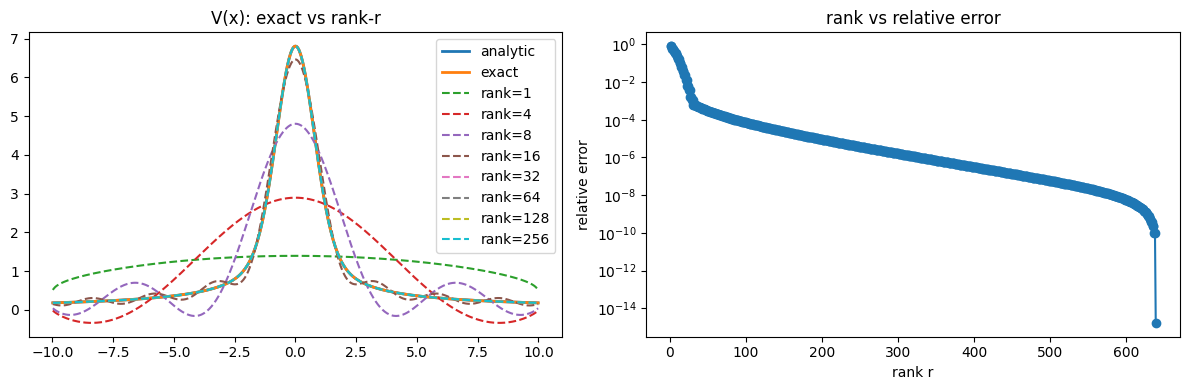

singular values: [368.5635 291.1144 259.314  237.434  221.571  208.6492 198.0807 188.9157
 181.002  173.91  ]
errors: {1: '7.92e-01', 2: '7.92e-01', 3: '5.94e-01', 4: '5.94e-01', 5: '4.53e-01', 6: '4.53e-01', 7: '3.28e-01', 8: '3.28e-01', 9: '2.34e-01', 10: '2.34e-01', 11: '1.58e-01', 12: '1.58e-01', 13: '1.05e-01', 14: '1.05e-01', 15: '6.51e-02', 16: '6.51e-02', 17: '3.99e-02', 18: '3.99e-02', 19: '2.24e-02', 20: '2.24e-02', 21: '1.29e-02', 22: '1.29e-02', 23: '6.43e-03', 24: '6.43e-03', 25: '3.69e-03', 26: '3.69e-03', 27: '1.59e-03', 28: '1.59e-03', 29: '1.16e-03', 30: '1.16e-03', 31: '6.36e-04', 32: '6.36e-04', 33: '6.35e-04', 34: '6.35e-04', 35: '5.20e-04', 36: '5.20e-04', 37: '4.93e-04', 38: '4.93e-04', 39: '4.45e-04', 40: '4.45e-04', 41: '4.12e-04', 42: '4.12e-04', 43: '3.80e-04', 44: '3.80e-04', 45: '3.52e-04', 46: '3.52e-04', 47: '3.26e-04', 48: '3.26e-04', 49: '3.03e-04', 50: '3.03e-04', 51: '2.82e-04', 52: '2.82e-04', 53: '2.63e-04', 54: '2.63e-04', 55: '2.46e-04', 56: '2.46e

In [3]:
# ---- グリッド ----
N = 640
L = 20.0
dx = L / N
eps = 0.05  # Lorentzian正則化

coords = (np.arange(N) - (N - 1) / 2.0) * dx  # shape (N,)

# ---- カーネル K_ij = 1/((x_i - d_j)^2 + eps^2) ----
xi = coords[:, None]  # (N, 1)
dj = coords[None, :]  # (1, N)
K = 1.0 / (((xi - dj)**2 + eps**2))**0.5  # (N, N)

# ---- 電荷密度 ----
alpha = 1.0
rho = np.exp(-alpha * coords**2)  # (N,)

# ---- 正解----
# V_exact = v_analytic_lorentzian(coords, alpha, eps)  # (N,)
V_exact = K @ rho * dx  # (N,)

# ---- SVD → rank-r 近似 ----
U, s, Vt = np.linalg.svd(K)

ranks = [i for i in range(1, N)]  # rank 1, 2, ..., 64
errors = []

for r in ranks:
    K_r = (U[:, :r] * s[:r]) @ Vt[:r, :]
    V_r = K_r @ rho * dx
    err = relative_error(V_exact, V_r)
    errors.append(err)

# ---- プロット ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左: V の比較
axes[0].plot(coords, V_exact, label="analytic", lw=2)
axes[0].plot(coords, K @ rho * dx, label="exact", lw=2)
for r in [1, 4, 8, 16, 32, 64, 128, 256]:
    K_r = (U[:, :r] * s[:r]) @ Vt[:r, :]
    V_r = K_r @ rho * dx
    axes[0].plot(coords, V_r, "--", label=f"rank={r}")
axes[0].set_title("V(x): exact vs rank-r")
axes[0].legend()

# 右: rank vs 相対誤差
axes[1].semilogy(ranks, errors, "o-")
axes[1].set_xlabel("rank r")
axes[1].set_ylabel("relative error")
axes[1].set_title("rank vs relative error")

plt.tight_layout()
plt.show()

# ---- 特異値の減衰 ----
print("singular values:", s[:10].round(4))
print("errors:", dict(zip(ranks, [f"{e:.2e}" for e in errors])))

近距離成分と遠距離成分に分離

(640, 640) bool


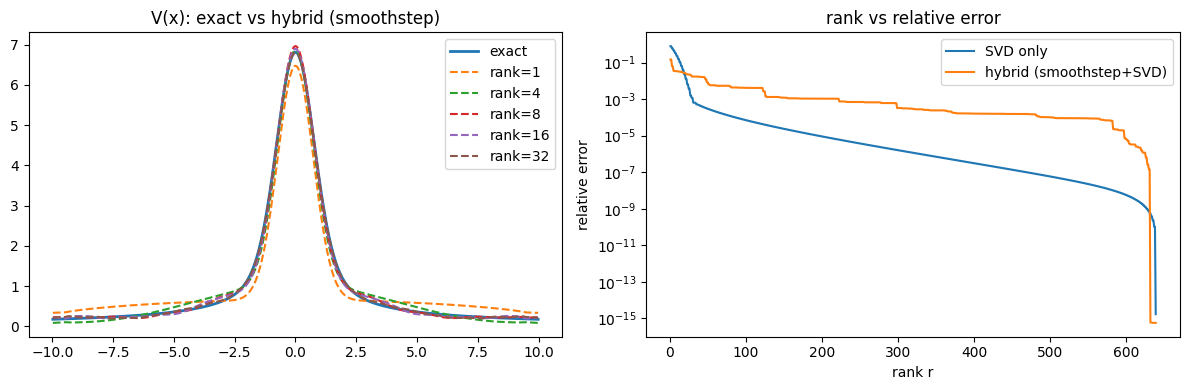

far singular values: [175.177465  98.164326  66.913542  45.794814  30.873514  30.03972
  30.03194   29.672769  29.640909  29.064491]


In [ ]:
# ---- グリッド ----
N = 640
L = 20.0
dx = L / N
eps = 0.05

coords = (np.arange(N) - (N - 1) / 2.0) * dx

xi = coords[:, None]
dj = coords[None, :]
diff = xi - dj
K = 1.0 / (diff**2 + eps**2)**0.5

alpha = 1.0
rho = np.exp(-alpha * coords**2)

V_exact = K @ rho * dx

# ---- 近傍/遠距離分割 ----
threshold = 10 * eps
near_mask = np.abs(diff) <= threshold
print(near_mask.shape, near_mask.dtype)
K_near = K * near_mask
K_far  = K * ~near_mask

# ---- 遠距離をSVD ----
U, s, Vt = np.linalg.svd(K)

ranks = [i for i in range(1, N)]
errors_svd = []  # 通常SVD（K全体）
errors_hybrid = []  # 近傍直接 + 遠距離SVD

U_far, s_far, Vt_far = np.linalg.svd(K_far)

for r in ranks:
    # 通常SVD
    K_r = (U[:, :r] * s[:r]) @ Vt[:r, :]
    V_r = K_r @ rho * dx
    errors_svd.append(relative_error(V_exact, V_r))

    # hybrid: 近傍直接 + 遠距離SVD
    V_h = K_near @ rho * dx + (U_far[:, :r] * s_far[:r]) @ Vt_far[:r, :] @ rho * dx
    errors_hybrid.append(relative_error(V_exact, V_h))

# ---- プロット ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(coords, V_exact, label="exact", lw=2)
for r in [1, 4, 8, 16, 32]:
    V_h = K_near @ rho * dx + (U_far[:, :r] * s_far[:r]) @ Vt_far[:r, :] @ rho * dx
    axes[0].plot(coords, V_h, "--", label=f"rank={r}")
axes[0].set_title("V(x): exact vs hybrid (smoothstep)")
axes[0].legend()

axes[1].semilogy(ranks, errors_svd,    label="SVD only")
axes[1].semilogy(ranks, errors_hybrid, label="hybrid (near direct + far SVD)")
axes[1].set_xlabel("rank r")
axes[1].set_ylabel("relative error")
axes[1].set_title("rank vs relative error")
axes[1].legend()

plt.tight_layout()
plt.show()

print("far singular values:", s_far[:10].round(6))

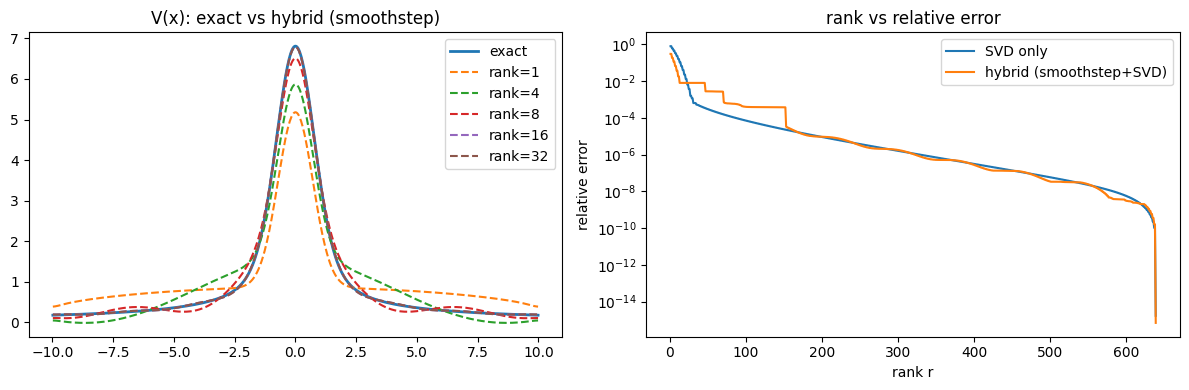

threshold=0.5000, near density=0.0248
far singular values: [228.343356 151.023014 119.375569  97.702651  82.091296  69.478036
  59.265059  50.512217  43.057898  36.481238]


In [10]:
# ---- グリッド ----
N = 640
L = 20.0
dx = L / N
eps = 0.05

coords = (np.arange(N) - (N - 1) / 2.0) * dx

xi = coords[:, None]
dj = coords[None, :]
diff = xi - dj
K = 1.0 / (diff**2 + eps**2)**0.5

alpha = 1.0
rho = np.exp(-alpha * coords**2)

V_exact = K @ rho * dx

# ---- smoothstep窓関数 ----
threshold = 10 * eps  # 調整パラメータ

def smoothstep(u, threshold):
    t = np.clip(np.abs(u) / threshold, 0, 1)
    return 1 - 3*t**2 + 2*t**3  # C1連続、両端で傾き=0

w = smoothstep(diff, threshold)   # (N, N)  近傍=1, 遠距離=0
K_near = K * w                    # スパース近傍（直接計算用）
K_far   = K * (1 - w)             # 滑らかな遠距離（SVD用）

# ---- SVD（全体 vs 遠距離）----
U_full, s_full, Vt_full = np.linalg.svd(K)
U_far,  s_far,  Vt_far  = np.linalg.svd(K_far)

ranks = list(range(1, N))
errors_svd    = []
errors_hybrid = []

for r in ranks:
    # 通常SVD
    V_r = (U_full[:, :r] * s_full[:r]) @ Vt_full[:r, :] @ rho * dx
    errors_svd.append(relative_error(V_exact, V_r))

    # hybrid: 近傍直接 + 遠距離SVD
    V_h = K_near @ rho * dx + (U_far[:, :r] * s_far[:r]) @ Vt_far[:r, :] @ rho * dx
    errors_hybrid.append(relative_error(V_exact, V_h))

# ---- プロット ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(coords, V_exact, label="exact", lw=2)
for r in [1, 4, 8, 16, 32]:
    V_h = K_near @ rho * dx + (U_far[:, :r] * s_far[:r]) @ Vt_far[:r, :] @ rho * dx
    axes[0].plot(coords, V_h, "--", label=f"rank={r}")
axes[0].set_title("V(x): exact vs hybrid (smoothstep)")
axes[0].legend()

axes[1].semilogy(ranks, errors_svd,    label="SVD only")
axes[1].semilogy(ranks, errors_hybrid, label="hybrid (smoothstep+SVD)")
axes[1].set_xlabel("rank r")
axes[1].set_ylabel("relative error")
axes[1].set_title("rank vs relative error")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"threshold={threshold:.4f}, near density={w.mean():.4f}")
print("far singular values:", s_far[:10].round(6))

分離にrobust PCAを試してみる

RPCA 実行中...
収束: iter=32, err=6.91e-07
L の実効ランク: 110
S の非ゼロ率: 0.1652


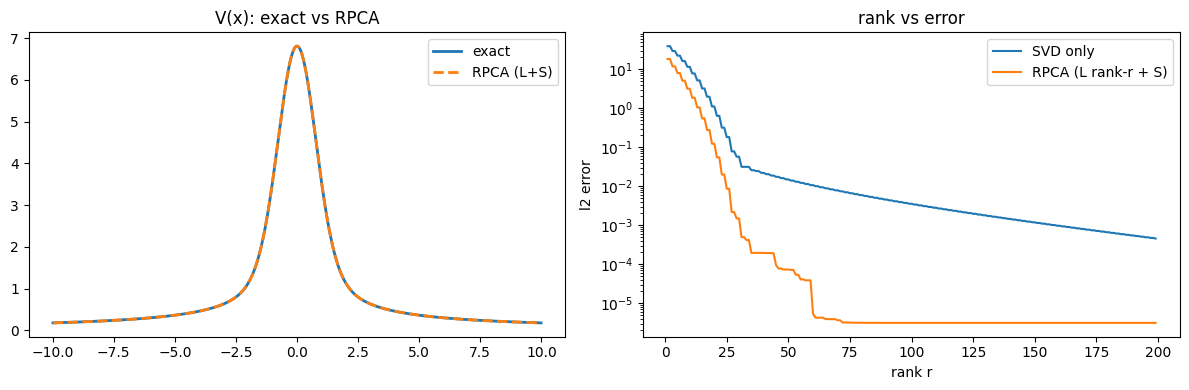

In [11]:
def rpca(M, lam=None, max_iter=1000, tol=1e-6):
    m, n = M.shape
    if lam is None:
        lam = 1.0 / np.sqrt(max(m, n))  # 修正①

    L = np.zeros_like(M)
    S = np.zeros_like(M)
    Y = np.zeros_like(M)
    norm2 = np.linalg.norm(M, ord=2)  # 最大特異値
    mu = 1.25 / norm2
    mu_inv = 1.0 / mu
    rho = 1.5  # 追加②

    for i in range(max_iter):
        U, s, Vt = np.linalg.svd(M - S + mu_inv * Y, full_matrices=False)
        L = (U * np.maximum(s - mu_inv, 0)) @ Vt

        Z = M - L + mu_inv * Y
        S = np.sign(Z) * np.maximum(np.abs(Z) - lam * mu_inv, 0)

        residual = M - L - S
        Y += mu * residual

        err = np.linalg.norm(residual) / np.linalg.norm(M)
        if err < tol:
            print(f"収束: iter={i+1}, err={err:.2e}")
            break

        mu = min(rho * mu, mu * 1e7)  # 追加②
        mu_inv = 1.0 / mu

    return L, S

# ---- 実行 ----
print("RPCA 実行中...")
L, S = rpca(K)

print(f"L の実効ランク: {(np.linalg.svd(L, compute_uv=False) > 1e-6).sum()}")
print(f"S の非ゼロ率: {(np.abs(S) > 1e-6).mean():.4f}")

# ---- ポテンシャル計算 ----
V_rpca = (L + S) @ rho * dx

# ---- rank-r 近似との比較 ----
U_L, s_L, Vt_L = np.linalg.svd(L)

ranks = list(range(1, 200))
errors_svd   = []
errors_rpca  = []

U_full, s_full, Vt_full = np.linalg.svd(K)

for r in ranks:
    V_r = (U_full[:, :r] * s_full[:r]) @ Vt_full[:r, :] @ rho * dx
    errors_svd.append(np.linalg.norm(V_r - V_exact))

    V_r_rpca = (U_L[:, :r] * s_L[:r]) @ Vt_L[:r, :] @ rho * dx + S @ rho * dx
    errors_rpca.append(np.linalg.norm(V_r_rpca - V_exact))

# ---- プロット ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(coords, V_exact, label="exact", lw=2)
axes[0].plot(coords, V_rpca,  label="RPCA (L+S)", lw=2, ls="--")
axes[0].set_title("V(x): exact vs RPCA")
axes[0].legend()

axes[1].semilogy(ranks, errors_svd,  label="SVD only")
axes[1].semilogy(ranks, errors_rpca, label="RPCA (L rank-r + S)")
axes[1].set_xlabel("rank r")
axes[1].set_ylabel("l2 error")
axes[1].set_title("rank vs error")
axes[1].legend()

plt.tight_layout()
plt.show()

Sが対角に集中しているか確認

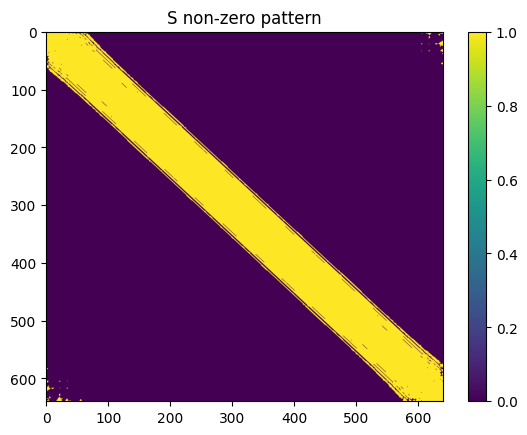

In [12]:
plt.imshow(np.abs(S) > 1e-6, aspect='auto')
plt.title("S non-zero pattern")
plt.colorbar()
plt.show()

randomized SVD を用いて計算量を減らす

RPCA 実行中...
収束: iter=30, err=7.96e-07
L の実効ランク: 99
S の非ゼロ率: 0.1486


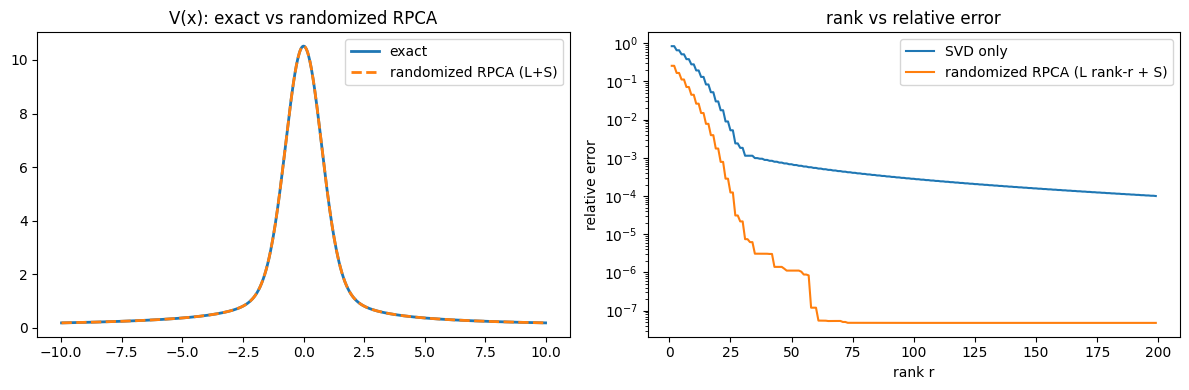

In [13]:
from sklearn.utils.extmath import randomized_svd

# ---- グリッド ----
N = 640
L = 20.0
dx = L / N
eps = 0.01

coords = (np.arange(N) - (N - 1) / 2.0) * dx

xi = coords[:, None]
dj = coords[None, :]
diff = xi - dj
K = 1.0 / ((diff**2 + eps**2)**0.5)

alpha = 1.0
rho = np.exp(-alpha * coords**2)

# ---- 正解----
V_exact = K @ rho * dx

def randomized_rpca(M, lam=None, rank=130, max_iter=1000, tol=1e-6):
    m, n = M.shape
    if lam is None:
        lam = 1.0 / np.sqrt(max(m, n))

    L = np.zeros_like(M)
    S = np.zeros_like(M)
    Y = np.zeros_like(M)
    mu = 1.25 / np.linalg.norm(M, ord=2)
    mu_inv = 1.0 / mu
    rho = 1.5

    for i in range(max_iter):
        U, s, Vt = randomized_svd(M - S + mu_inv * Y, 
                                   n_components=rank,
                                   random_state=0)
        L = (U * np.maximum(s - mu_inv, 0)) @ Vt

        Z = M - L + mu_inv * Y
        S = np.sign(Z) * np.maximum(np.abs(Z) - lam * mu_inv, 0)

        residual = M - L - S
        Y += mu * residual

        err = np.linalg.norm(residual) / np.linalg.norm(M)
        if err < tol:
            print(f"収束: iter={i+1}, err={err:.2e}")
            break

        mu = min(rho * mu, mu * 1e7)
        mu_inv = 1.0 / mu

    return L, S

# ---- 実行 ----
print("RPCA 実行中...")
L, S = randomized_rpca(K)

print(f"L の実効ランク: {(np.linalg.svd(L, compute_uv=False) > 1e-6).sum()}")
print(f"S の非ゼロ率: {(np.abs(S) > 1e-6).mean():.4f}")

# ---- ポテンシャル計算 ----
V_rpca = (L + S) @ rho * dx

# ---- rank-r 近似との比較 ----
U_L, s_L, Vt_L = np.linalg.svd(L)

ranks = list(range(1, 200))
errors_svd   = []
errors_rpca  = []

U_full, s_full, Vt_full = np.linalg.svd(K)

for r in ranks:
    V_r = (U_full[:, :r] * s_full[:r]) @ Vt_full[:r, :] @ rho * dx
    errors_svd.append(relative_error(V_exact, V_r))

    V_r_rpca = (U_L[:, :r] * s_L[:r]) @ Vt_L[:r, :] @ rho * dx + S @ rho * dx
    errors_rpca.append(relative_error(V_exact, V_r_rpca))

# ---- プロット ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(coords, V_exact, label="exact", lw=2)
axes[0].plot(coords, V_rpca,  label="randomized RPCA (L+S)", lw=2, ls="--")
axes[0].set_title("V(x): exact vs randomized RPCA")
axes[0].legend()

axes[1].semilogy(ranks, errors_svd,  label="SVD only")
axes[1].semilogy(ranks, errors_rpca, label="randomized RPCA (L rank-r + S)")
axes[1].set_xlabel("rank r")
axes[1].set_ylabel("relative error")
axes[1].set_title("rank vs relative error")
axes[1].legend()

plt.tight_layout()
plt.show()

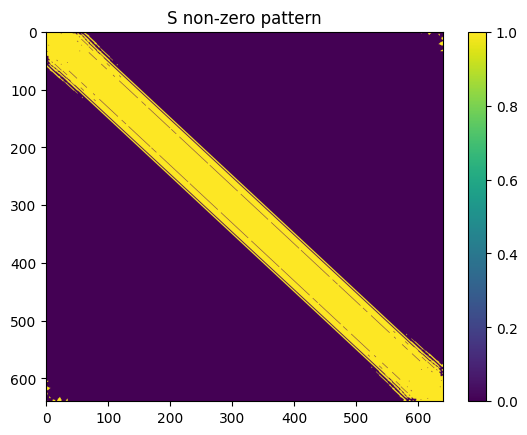

In [14]:
plt.imshow(np.abs(S) > 1e-6, aspect='auto')
plt.title("S non-zero pattern")
plt.colorbar()
plt.show()

In [15]:
def plot_kernel_from_matrix(K, coords, threshold=None):
    """
    N×N 行列 K から K(r) を抽出してプロット。

    Parameters
    ----------
    K         : (N, N) ndarray  ← コードの K をそのまま渡す
    coords    : (N,)   ndarray  ← コードの coords をそのまま渡す
    threshold : float or None   ← 指定すれば K_near/K_far も重ねる
    """
    import numpy as np
    import matplotlib.pyplot as plt

    K_arr = np.asarray(K)
    coords_arr = np.asarray(coords)

    if K_arr.ndim != 2 or K_arr.shape[0] != K_arr.shape[1]:
        raise ValueError(
            f"K must be a square 2D array, but got shape={K_arr.shape}. "
            "If you passed scalar L (domain length), use a matrix such as K, S, or K-S."
        )
    if coords_arr.ndim != 1 or coords_arr.shape[0] != K_arr.shape[0]:
        raise ValueError(
            f"coords must be 1D with length {K_arr.shape[0]}, but got shape={coords_arr.shape}."
        )

    N = K_arr.shape[0]
    mid = N // 2

    r = coords_arr - coords_arr[mid]   # r = xj - x_mid
    k_slice = K_arr[mid, :]            # K(x_mid, xj) として r の関数を抽出

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(r, k_slice, lw=2.5, label=r"$K(r)$ from matrix")

    ax.set_xlabel(r"$r = x_j - x_\mathrm{mid}$")
    ax.set_ylabel(r"$K(r)$")
    ax.set_title("K(r) extracted from matrix (center row)")
    ax.set_ylim(bottom=0)
    ax.legend()
    plt.tight_layout()
    plt.show()

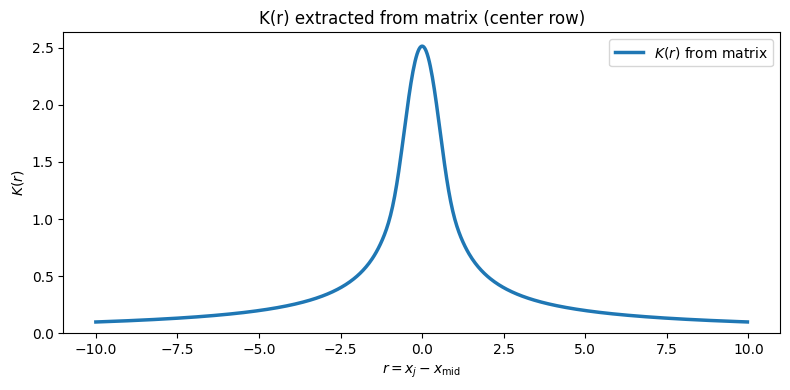

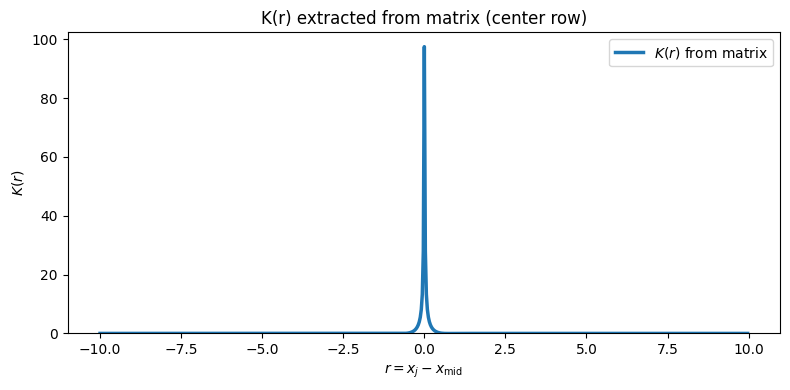

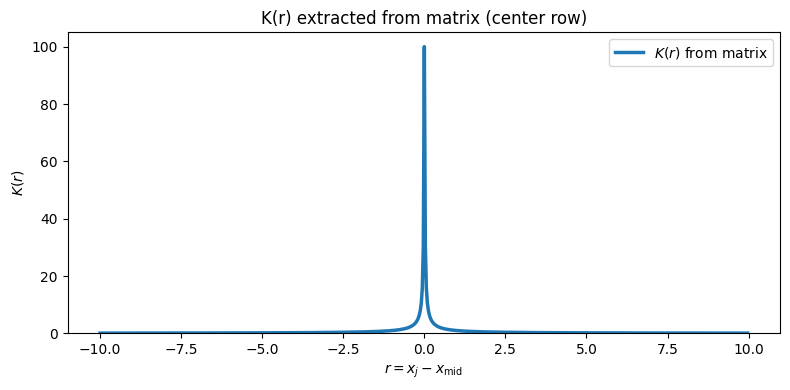

In [16]:
L_mat = K - S if np.isscalar(L) else L

plot_kernel_from_matrix(L_mat, coords)
plot_kernel_from_matrix(S, coords)
plot_kernel_from_matrix(K, coords)